In [ ]:
import gc

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import gc

In [73]:
refseq_header = '''#gtf-version 2.2
#!genome-build GRCh38.p14
#!genome-build-accession NCBI_Assembly:GCF_000001405.40
#!annotation-date 08/23/2024
#!annotation-source NCBI RefSeq GCF_000001405.40-RS_2024_08
'''

ensembl_header = '''#!genome-build GRCh38.p14
#!genome-version GRCh38
#!genome-date 2013-12
#!genome-build-accession GCA_000001405.29
#!genebuild-last-updated 2024-07
'''


In [ ]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [35]:
refseq_path = "/extdata4/baeklab/Hyeonseo/m6A/anno/GCF_000001405.40_GRCh38.p14_genomic.gtf"
ensembl_path = "/extdata4/baeklab/Hyeonseo/m6A/anno/Homo_sapiens.GRCh38.113.gtf"

In [36]:
columns = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]

refseq = pd.read_csv(refseq_path, sep= "\t", skiprows=5, names = columns, dtype={"chr":str})
ensembl = pd.read_csv(ensembl_path, sep= "\t", skiprows=5, names = columns, dtype={"chr":str})

print(refseq)
print(ensembl)

                  chr      source     feature    start      end score strand  \
0        NC_000001.11  BestRefSeq        gene  11874.0  14409.0     .      +   
1        NC_000001.11  BestRefSeq  transcript  11874.0  14409.0     .      +   
2        NC_000001.11  BestRefSeq        exon  11874.0  12227.0     .      +   
3        NC_000001.11  BestRefSeq        exon  12613.0  12721.0     .      +   
4        NC_000001.11  BestRefSeq        exon  13221.0  14409.0     .      +   
...               ...         ...         ...      ...      ...   ...    ...   
4697661   NC_012920.1      RefSeq        exon  15888.0  15953.0     .      +   
4697662   NC_012920.1      RefSeq        gene  15956.0  16023.0     .      -   
4697663   NC_012920.1      RefSeq  transcript  15956.0  16023.0     .      -   
4697664   NC_012920.1      RefSeq        exon  15956.0  16023.0     .      -   
4697665           ###         NaN         NaN      NaN      NaN   NaN    NaN   

        frame                          

In [37]:

def ncid_to_chr(ncid):
    ncid_int=ncid.split(".")[0][3:]
    if not ncid_int.isnumeric():
        return "chrUnk"
    else:
        ncid_int = int(ncid_int)
    if ncid_int<=22:
        chr=f"chr{ncid_int}"
    elif ncid_int==23:
        chr="chrX"
    elif ncid_int==24:
        chr="chrY"
    else:
        chr="chrUnk"
    return chr

In [38]:
valid_chr = ["chr"+str(x) for x in range(1,24)]+["chrX","chrY"]

In [39]:
refseq["chr"] = refseq["chr"].apply(ncid_to_chr)
refseq_filtered = refseq[refseq["chr"].isin(valid_chr)]
print(refseq_filtered)

          chr      source     feature       start         end score strand  \
0        chr1  BestRefSeq        gene     11874.0     14409.0     .      +   
1        chr1  BestRefSeq  transcript     11874.0     14409.0     .      +   
2        chr1  BestRefSeq        exon     11874.0     12227.0     .      +   
3        chr1  BestRefSeq        exon     12613.0     12721.0     .      +   
4        chr1  BestRefSeq        exon     13221.0     14409.0     .      +   
...       ...         ...         ...         ...         ...   ...    ...   
4291877  chrY  BestRefSeq        gene  57212178.0  57214703.0     .      -   
4291878  chrY  BestRefSeq  transcript  57212178.0  57214703.0     .      -   
4291879  chrY  BestRefSeq        exon  57214350.0  57214703.0     .      -   
4291880  chrY  BestRefSeq        exon  57213856.0  57213964.0     .      -   
4291881  chrY  BestRefSeq        exon  57212178.0  57213357.0     .      -   

        frame                                          attribut

In [40]:
ensembl["chr"] = "chr"+ensembl["chr"]
ensembl_filtered = ensembl[ensembl["chr"].isin(valid_chr)]
print(ensembl_filtered)

           chr          source      feature    start      end score strand  \
0         chr1  ensembl_havana         gene  3069168  3438621     .      +   
1         chr1          havana   transcript  3069168  3434342     .      +   
2         chr1          havana         exon  3069168  3069296     .      +   
3         chr1          havana          CDS  3069260  3069296     .      +   
4         chr1          havana  start_codon  3069260  3069262     .      +   
...        ...             ...          ...      ...      ...   ...    ...   
4102141  chr21   havana_tagene         exon  9678230  9678353     .      +   
4102142  chr21   havana_tagene         exon  9679515  9679891     .      +   
4102143  chr21   havana_tagene   transcript  9662173  9677705     .      +   
4102144  chr21   havana_tagene         exon  9662173  9662338     .      +   
4102145  chr21   havana_tagene         exon  9677372  9677705     .      +   

        frame                                          attribut

In [115]:
print(ensembl_filtered["chr"].value_counts())

chr
chr1     384044
chr2     317125
chr3     258906
chr11    229975
chr17    227583
chr12    220289
chr7     209108
chr19    206500
chr6     201830
chr5     192647
chr16    174382
chr4     173346
chr9     169568
chr10    162994
chr8     155217
chr15    147604
chr14    139726
chrX     136367
chr20     95761
chr22     86095
chr13     75150
chr18     73574
chr21     49887
chrY      14468
Name: count, dtype: int64


In [114]:
print(refseq_filtered["chr"].value_counts())

chr
chr1     420833
chr2     372655
chr3     295092
chr12    242700
chr17    238481
chr11    232206
chr6     208951
chr10    199516
chr9     192461
chr7     187653
chr4     187055
chr19    183061
chr5     181816
chr8     165403
chr16    163634
chr15    154774
chr14    135440
chrX     127946
chr18     87517
chr20     86874
chr13     86819
chr22     83781
chr21     41579
chrY      14236
Name: count, dtype: int64


In [116]:
refseq_filtered[["start", "end"]] = refseq_filtered[["start", "end"]].astype(int)

/tmp/ipykernel_36207/2087530877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refseq_filtered[["start", "end"]] = refseq_filtered[["start", "end"]].astype(int)


In [120]:
refseq_filtered[columns].copy().to_csv("/extdata4/baeklab/Hyeonseo/m6A/anno/refseq_filtered.gtf", sep="\t", index=False, header=False,  quoting=3)
ensembl_filtered[columns].copy().to_csv("/extdata4/baeklab/Hyeonseo/m6A/anno/ensembl_filtered.gtf", sep="\t", index=False, header=False,  quoting=3)

In [119]:
print(refseq_filtered)

          chr      source     feature     start       end score strand frame  \
0        chr1  BestRefSeq        gene     11874     14409     .      +     .   
1        chr1  BestRefSeq  transcript     11874     14409     .      +     .   
2        chr1  BestRefSeq        exon     11874     12227     .      +     .   
3        chr1  BestRefSeq        exon     12613     12721     .      +     .   
4        chr1  BestRefSeq        exon     13221     14409     .      +     .   
...       ...         ...         ...       ...       ...   ...    ...   ...   
4291877  chrY  BestRefSeq        gene  57212178  57214703     .      -     .   
4291878  chrY  BestRefSeq  transcript  57212178  57214703     .      -     .   
4291879  chrY  BestRefSeq        exon  57214350  57214703     .      -     .   
4291880  chrY  BestRefSeq        exon  57213856  57213964     .      -     .   
4291881  chrY  BestRefSeq        exon  57212178  57213357     .      -     .   

                                       

In [121]:
merged_path = "/extdata4/baeklab/Hyeonseo/m6A/anno/merged_gtf_manual.gtf"
merged_filtered = pd.read_csv(merged_path, sep= "\t", names = columns)
print(merged_filtered)

          chr         source     feature     start       end score strand  \
0        chr1         havana        gene     11121     24894     .      +   
1        chr1  havana_tagene  transcript     11121     14413     .      +   
2        chr1  havana_tagene        exon     11121     11211     .      +   
3        chr1  havana_tagene        exon     12010     12227     .      +   
4        chr1  havana_tagene        exon     12613     12721     .      +   
...       ...            ...         ...       ...       ...   ...    ...   
7828160  chrY         havana        exon  57214350  57214397     .      -   
7828161  chrY         havana        exon  57213880  57213964     .      -   
7828162  chrY         havana        exon  57213526  57213602     .      -   
7828163  chrY         havana        exon  57213204  57213357     .      -   
7828164  chrY         havana        exon  57212184  57213125     .      -   

        frame                                          attribute  
0       

In [122]:
merged_filtered_exon = merged_filtered[merged_filtered["feature"]=="exon"]

In [43]:
ensembl_filtered_exon = ensembl_filtered[ensembl_filtered["feature"]=="exon"]
refseq_filtered_exon = refseq_filtered[refseq_filtered["feature"]=="exon"]

print(ensembl_filtered_exon)
print(refseq_filtered_exon)

           chr         source feature    start      end score strand frame  \
2         chr1         havana    exon  3069168  3069296     .      +     .   
5         chr1         havana    exon  3186125  3186474     .      +     .   
7         chr1         havana    exon  3244087  3244137     .      +     .   
9         chr1         havana    exon  3385149  3385286     .      +     .   
11        chr1         havana    exon  3396491  3396593     .      +     .   
...        ...            ...     ...      ...      ...   ...    ...   ...   
4102140  chr21  havana_tagene    exon  9677372  9677569     .      +     .   
4102141  chr21  havana_tagene    exon  9678230  9678353     .      +     .   
4102142  chr21  havana_tagene    exon  9679515  9679891     .      +     .   
4102144  chr21  havana_tagene    exon  9662173  9662338     .      +     .   
4102145  chr21  havana_tagene    exon  9677372  9677705     .      +     .   

                                                 attribute  
2 

In [50]:
print(ensembl_filtered_exon["attribute"].values[0])

gene_id "ENSG00000142611"; gene_version "17"; transcript_id "ENST00000511072"; transcript_version "5"; exon_number "1"; gene_name "PRDM16"; gene_source "ensembl_havana"; gene_biotype "protein_coding"; transcript_name "PRDM16-206"; transcript_source "havana"; transcript_biotype "protein_coding"; exon_id "ENSE00002048533"; exon_version "1"; tag "gencode_basic"; tag "gencode_primary"; transcript_support_level "5";


In [51]:
print(refseq_filtered_exon["attribute"].values[0])

gene_id "DDX11L1"; transcript_id "NR_046018.2"; db_xref "GeneID:100287102"; db_xref "GenBank:NR_046018.2"; db_xref "HGNC:HGNC:37102"; gene "DDX11L1"; product "DEAD/H-box helicase 11 like 1 (pseudogene)"; pseudo "true"; transcript_biotype "transcript"; exon_number "1"; 


In [124]:
print(merged_filtered_exon["attribute"].values[0])

gene_id "ENSG00000290825"; gene_version "2"; transcript_id "ENST00000832824"; transcript_version "1"; exon_number "1"; gene_name "DDX11L16"; gene_source "havana"; gene_biotype "lncRNA"; transcript_name "DDX11L16-260"; transcript_source "havana_tagene"; transcript_biotype "lncRNA"; exon_id "ENSE00004248723"; exon_version "1";


In [68]:
def attribute_to_dict(attribute):
    attribute_dict = {}
    for attr in attribute.split(";")[:-1]:
        key, value = attr.split('"')[:2]
        key = key.strip()
        attribute_dict[key] = value
    return attribute_dict

In [69]:
print(attribute_to_dict(ensembl_filtered_exon["attribute"].values[0]))

{'gene_id': 'ENSG00000142611', 'gene_version': '17', 'transcript_id': 'ENST00000511072', 'transcript_version': '5', 'exon_number': '1', 'gene_name': 'PRDM16', 'gene_source': 'ensembl_havana', 'gene_biotype': 'protein_coding', 'transcript_name': 'PRDM16-206', 'transcript_source': 'havana', 'transcript_biotype': 'protein_coding', 'exon_id': 'ENSE00002048533', 'exon_version': '1', 'tag': 'gencode_primary', 'transcript_support_level': '5'}


In [70]:
print(attribute_to_dict(refseq_filtered_exon["attribute"].values[0]))

{'gene_id': 'DDX11L1', 'transcript_id': 'NR_046018.2', 'db_xref': 'HGNC:HGNC:37102', 'gene': 'DDX11L1', 'product': 'DEAD/H-box helicase 11 like 1 (pseudogene)', 'pseudo': 'true', 'transcript_biotype': 'transcript', 'exon_number': '1'}


In [123]:
merged_filtered_exon = merged_filtered_exon.reset_index(drop=True)
merged_filtered_exon["attribute_dict"] = merged_filtered_exon["attribute"].apply(attribute_to_dict)

In [71]:
ensembl_filtered_exon = ensembl_filtered_exon.copy().reset_index(drop=True)
ensembl_filtered_exon["attribute_dict"] = ensembl_filtered_exon["attribute"].apply(attribute_to_dict)
print(ensembl_filtered_exon)

           chr         source feature    start      end score strand frame  \
0         chr1         havana    exon  3069168  3069296     .      +     .   
1         chr1         havana    exon  3186125  3186474     .      +     .   
2         chr1         havana    exon  3244087  3244137     .      +     .   
3         chr1         havana    exon  3385149  3385286     .      +     .   
4         chr1         havana    exon  3396491  3396593     .      +     .   
...        ...            ...     ...      ...      ...   ...    ...   ...   
2154963  chr21  havana_tagene    exon  9677372  9677569     .      +     .   
2154964  chr21  havana_tagene    exon  9678230  9678353     .      +     .   
2154965  chr21  havana_tagene    exon  9679515  9679891     .      +     .   
2154966  chr21  havana_tagene    exon  9662173  9662338     .      +     .   
2154967  chr21  havana_tagene    exon  9677372  9677705     .      +     .   

                                                 attribute  \
0

In [72]:
refseq_filtered_exon = refseq_filtered_exon.copy().reset_index(drop=True)
refseq_filtered_exon["attribute_dict"] = refseq_filtered_exon["attribute"].apply(attribute_to_dict)
print(refseq_filtered_exon)

          chr      source feature       start         end score strand frame  \
0        chr1  BestRefSeq    exon     11874.0     12227.0     .      +     .   
1        chr1  BestRefSeq    exon     12613.0     12721.0     .      +     .   
2        chr1  BestRefSeq    exon     13221.0     14409.0     .      +     .   
3        chr1  BestRefSeq    exon     29321.0     29370.0     .      -     .   
4        chr1  BestRefSeq    exon     24738.0     24891.0     .      -     .   
...       ...         ...     ...         ...         ...   ...    ...   ...   
2105808  chrY  BestRefSeq    exon  57203182.0  57203350.0     .      -     .   
2105809  chrY  BestRefSeq    exon  57201084.0  57202145.0     .      -     .   
2105810  chrY  BestRefSeq    exon  57214350.0  57214703.0     .      -     .   
2105811  chrY  BestRefSeq    exon  57213856.0  57213964.0     .      -     .   
2105812  chrY  BestRefSeq    exon  57212178.0  57213357.0     .      -     .   

                                       

In [74]:
refseq_filtered_exon["coding"] = refseq_filtered_exon["attribute_dict"].apply(lambda x: x.get("transcript_id", "XXXX")[1]=="M")

In [75]:
ensembl_filtered_exon["coding"] = ensembl_filtered_exon["attribute_dict"].apply(lambda x: x.get("transcript_biotype", "XXXX")=="protein_coding")

In [125]:
def determine_coding(attribute_dict):
    transcript_id = attribute_dict.get("transcript_id", "XXXX")
    if transcript_id.startswith("NM") or transcript_id.startswith("XM"):
        return True
    else:
        transcript_biotype = attribute_dict.get("transcript_biotype", "XXXX")
        return transcript_biotype=="protein_coding"

In [126]:
merged_filtered_exon["coding"] = merged_filtered_exon["attribute_dict"].apply(lambda x: determine_coding(x))

In [127]:
print(merged_filtered_exon)

          chr         source feature     start       end score strand frame  \
0        chr1  havana_tagene    exon     11121     11211     .      +     .   
1        chr1  havana_tagene    exon     12010     12227     .      +     .   
2        chr1  havana_tagene    exon     12613     12721     .      +     .   
3        chr1  havana_tagene    exon     13453     14413     .      +     .   
4        chr1  havana_tagene    exon     11125     11211     .      +     .   
...       ...            ...     ...       ...       ...   ...    ...   ...   
4024327  chrY         havana    exon  57214350  57214397     .      -     .   
4024328  chrY         havana    exon  57213880  57213964     .      -     .   
4024329  chrY         havana    exon  57213526  57213602     .      -     .   
4024330  chrY         havana    exon  57213204  57213357     .      -     .   
4024331  chrY         havana    exon  57212184  57213125     .      -     .   

                                                 at

In [76]:
print(refseq_filtered_exon)

          chr      source feature       start         end score strand frame  \
0        chr1  BestRefSeq    exon     11874.0     12227.0     .      +     .   
1        chr1  BestRefSeq    exon     12613.0     12721.0     .      +     .   
2        chr1  BestRefSeq    exon     13221.0     14409.0     .      +     .   
3        chr1  BestRefSeq    exon     29321.0     29370.0     .      -     .   
4        chr1  BestRefSeq    exon     24738.0     24891.0     .      -     .   
...       ...         ...     ...         ...         ...   ...    ...   ...   
2105808  chrY  BestRefSeq    exon  57203182.0  57203350.0     .      -     .   
2105809  chrY  BestRefSeq    exon  57201084.0  57202145.0     .      -     .   
2105810  chrY  BestRefSeq    exon  57214350.0  57214703.0     .      -     .   
2105811  chrY  BestRefSeq    exon  57213856.0  57213964.0     .      -     .   
2105812  chrY  BestRefSeq    exon  57212178.0  57213357.0     .      -     .   

                                       

In [77]:
print(ensembl_filtered_exon)

           chr         source feature    start      end score strand frame  \
0         chr1         havana    exon  3069168  3069296     .      +     .   
1         chr1         havana    exon  3186125  3186474     .      +     .   
2         chr1         havana    exon  3244087  3244137     .      +     .   
3         chr1         havana    exon  3385149  3385286     .      +     .   
4         chr1         havana    exon  3396491  3396593     .      +     .   
...        ...            ...     ...      ...      ...   ...    ...   ...   
2154963  chr21  havana_tagene    exon  9677372  9677569     .      +     .   
2154964  chr21  havana_tagene    exon  9678230  9678353     .      +     .   
2154965  chr21  havana_tagene    exon  9679515  9679891     .      +     .   
2154966  chr21  havana_tagene    exon  9662173  9662338     .      +     .   
2154967  chr21  havana_tagene    exon  9677372  9677705     .      +     .   

                                                 attribute  \
0

In [78]:
refseq_filtered_exon_coding = refseq_filtered_exon[refseq_filtered_exon["coding"]]
ensembl_filtered_exon_coding = ensembl_filtered_exon[ensembl_filtered_exon["coding"]]
refseq_filtered_exon_noncoding = refseq_filtered_exon[~refseq_filtered_exon["coding"]]
ensembl_filtered_exon_noncoding = ensembl_filtered_exon[~ensembl_filtered_exon["coding"]]

print(len(refseq_filtered_exon_coding), len(ensembl_filtered_exon_coding))
print(len(refseq_filtered_exon_noncoding), len(ensembl_filtered_exon_noncoding))

1835891 864003
269922 1290965


In [128]:
merged_filtered_exon_coding = merged_filtered_exon[merged_filtered_exon["coding"]]
merged_filtered_exon_noncoding = merged_filtered_exon[~merged_filtered_exon["coding"]]
print(len(merged_filtered_exon_coding), len(merged_filtered_exon_noncoding))

2477984 1546348


In [80]:
def write_gtf(df, path, header):
    columns = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]
    df = df[columns].copy()
    df["attribute"] = "."
    with open(path, "w") as f:
        f.write(header)
        df.to_csv(f, sep="\t", index=False, header=False)
    return None

In [81]:
write_gtf(refseq_filtered_exon_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/refseq_filtered_exon_coding.gtf", refseq_header)


In [82]:
write_gtf(ensembl_filtered_exon_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/ensembl_filtered_exon_coding.gtf", ensembl_header)


In [83]:
write_gtf(refseq_filtered_exon_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/refseq_filtered_exon_noncoding.gtf", refseq_header)

In [84]:
write_gtf(ensembl_filtered_exon_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/ensembl_filtered_exon_noncoding.gtf", ensembl_header)

In [85]:
write_gtf(refseq_filtered_exon, "/extdata4/baeklab/Hyeonseo/m6A/anno/refseq_filtered_exon.gtf", refseq_header)

In [86]:
write_gtf(ensembl_filtered_exon, "/extdata4/baeklab/Hyeonseo/m6A/anno/ensembl_filtered_exon.gtf", ensembl_header)

In [87]:
refseq_filtered_exon["gene_id"] = refseq_filtered_exon["attribute_dict"].apply(lambda x: x.get("gene_id", "NA"))
ensembl_filtered_exon["gene_id"] = ensembl_filtered_exon["attribute_dict"].apply(lambda x: x.get("gene_id", "NA"))

In [129]:
merged_filtered_exon["gene_id"] = merged_filtered_exon["attribute_dict"].apply(lambda x: x.get("gene_id", "NA"))

In [94]:
def filter_gtf(df):
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)
    df = df[df["start"]<df["end"]]
    df = df[df["start"]>0]
    df = df[df["gene_id"]!="NA"]
    return df

In [95]:
refseq_filtered_exon = filter_gtf(refseq_filtered_exon)
ensembl_filtered_exon = filter_gtf(ensembl_filtered_exon)


In [130]:
merged_filtered_exon = filter_gtf(merged_filtered_exon)

In [96]:
def write_bed(df, path):
    columns = ["chr", "start", "end", "gene_id", "score", "strand"]
    df = df[columns].copy()
    df.to_csv(path, sep="\t", index=False, header=False)
    return None
    

In [131]:
merged_filtered_exon_coding = merged_filtered_exon[merged_filtered_exon["coding"]]
merged_filtered_exon_noncoding = merged_filtered_exon[~merged_filtered_exon["coding"]]


In [97]:
refseq_filtered_exon_coding = refseq_filtered_exon[refseq_filtered_exon["coding"]]
ensembl_filtered_exon_coding = ensembl_filtered_exon[ensembl_filtered_exon["coding"]]
refseq_filtered_exon_noncoding = refseq_filtered_exon[~refseq_filtered_exon["coding"]]
ensembl_filtered_exon_noncoding = ensembl_filtered_exon[~ensembl_filtered_exon["coding"]]


In [98]:
write_bed(refseq_filtered_exon_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_exon_coding.bed")
write_bed(ensembl_filtered_exon_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_exon_coding.bed")
write_bed(refseq_filtered_exon_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_exon_noncoding.bed")
write_bed(ensembl_filtered_exon_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_exon_noncoding.bed")
write_bed(refseq_filtered_exon, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_exon.bed")
write_bed(ensembl_filtered_exon, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_exon.bed")

In [135]:
write_bed(merged_filtered_exon, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/merged_filtered_exon.bed")
write_bed(merged_filtered_exon_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/merged_filtered_exon_coding.bed")
write_bed(merged_filtered_exon_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/merged_filtered_exon_noncoding.bed")

In [102]:
cmd1 = "bedtools sort -i {bed} | bedtools merge -i - > {output}"
cmd2 = "bedtools intersect -a {bed1} -b {bed2} | bedtools sort -i - | bedtools merge -i - > {output}"


In [100]:
wdir = "/extdata4/baeklab/Hyeonseo/m6A/anno/bed"
refseq_exon_bed = os.path.join(wdir, "refseq_filtered_exon.bed")
ensembl_exon_bed = os.path.join(wdir, "ensembl_filtered_exon.bed")
refseq_coding_bed = os.path.join(wdir, "refseq_filtered_exon_coding.bed")
ensembl_coding_bed = os.path.join(wdir, "ensembl_filtered_exon_coding.bed")
refseq_noncoding_bed = os.path.join(wdir, "refseq_filtered_exon_noncoding.bed")
ensembl_noncoding_bed = os.path.join(wdir, "ensembl_filtered_exon_noncoding.bed")


In [133]:
merged_exon_bed = os.path.join(wdir, "merged_filtered_exon.bed")
merged_exon_coding_bed = os.path.join(wdir, "merged_filtered_exon_coding.bed")
merged_exon_noncoding_bed = os.path.join(wdir, "merged_filtered_exon_noncoding.bed")

In [103]:
for bed in [refseq_exon_bed, ensembl_exon_bed, refseq_coding_bed, ensembl_coding_bed, refseq_noncoding_bed, ensembl_noncoding_bed]:
    output = bed.replace(".bed", "_merged.bed")
    os.system(cmd1.format(bed=bed, output=output))

In [136]:
for bed in [merged_exon_bed, merged_exon_coding_bed, merged_exon_noncoding_bed]:
    output = bed.replace(".bed", "_merged.bed")
    os.system(cmd1.format(bed=bed, output=output))

In [104]:
pairs = [(refseq_exon_bed, ensembl_exon_bed), (refseq_coding_bed, ensembl_coding_bed), (refseq_noncoding_bed, ensembl_noncoding_bed)]
pairs = [(x[0].replace(".bed", "_merged.bed"), x[1].replace(".bed", "_merged.bed")) for x in pairs]
for bed1, bed2 in pairs:
    output = bed1.replace(".bed", "_intersect.bed")
    os.system(cmd2.format(bed1=bed1, bed2=bed2, output=output))

In [137]:
pairs = [(merged_exon_bed, refseq_exon_bed), (merged_exon_bed, ensembl_exon_bed), (merged_exon_coding_bed, refseq_coding_bed), (merged_exon_coding_bed, ensembl_coding_bed), (merged_exon_noncoding_bed, refseq_noncoding_bed), (merged_exon_noncoding_bed, ensembl_noncoding_bed)]
pairs = [(x[0].replace(".bed", "_merged.bed"), x[1].replace(".bed", "_merged.bed")) for x in pairs]
for bed1, bed2 in pairs:
    output = bed2.replace(".bed", "_intersect_with_merged.bed")
    os.system(cmd2.format(bed1=bed1, bed2=bed2, output=output))

In [140]:
pairs = [(merged_exon_bed, refseq_exon_bed.replace(".bed", "_merged_intersect.bed")), (merged_exon_coding_bed, refseq_coding_bed.replace(".bed", "_merged_intersect.bed")), (merged_exon_noncoding_bed, refseq_noncoding_bed.replace(".bed", "_merged_intersect.bed"))]
pairs = [(x[0].replace(".bed", "_merged.bed"), x[1]) for x in pairs]
for bed1, bed2 in pairs:
    output = bed1.replace(".bed", "_intersect_with_merged.bed")
    os.system(cmd2.format(bed1=bed1, bed2=bed2, output=output))

In [107]:
def get_total_coverage(bed):
    bed = pd.read_csv(bed, sep="\t", header=None)
    total_coverage = np.sum(np.abs(bed[2]-bed[1]))
    return total_coverage

In [109]:
refseq_exon_cov =  get_total_coverage(refseq_exon_bed.replace(".bed", "_merged.bed"))
ensembl_exon_cov = get_total_coverage(ensembl_exon_bed.replace(".bed", "_merged.bed"))
refseq_coding_cov = get_total_coverage(refseq_coding_bed.replace(".bed", "_merged.bed"))
ensembl_coding_cov = get_total_coverage(ensembl_coding_bed.replace(".bed", "_merged.bed"))
refseq_noncoding_cov = get_total_coverage(refseq_noncoding_bed.replace(".bed", "_merged.bed"))
ensembl_noncoding_cov = get_total_coverage(ensembl_noncoding_bed.replace(".bed", "_merged.bed"))
intersect_exon_cov = get_total_coverage(refseq_exon_bed.replace(".bed", "_merged_intersect.bed"))
intersect_coding_cov = get_total_coverage(refseq_coding_bed.replace(".bed", "_merged_intersect.bed"))
intersect_noncoding_cov = get_total_coverage(refseq_noncoding_bed.replace(".bed", "_merged_intersect.bed"))

print(refseq_exon_cov, ensembl_exon_cov, intersect_exon_cov)
print(refseq_coding_cov, ensembl_coding_cov, intersect_coding_cov)
print(refseq_noncoding_cov, ensembl_noncoding_cov, intersect_noncoding_cov)

146205705 184062915 100052929
99099184 83634212 75836695
62897911 134004618 30102077


In [150]:
merged_exon_cov = get_total_coverage(merged_exon_bed.replace(".bed", "_merged.bed"))
merged_exon_coding_cov = get_total_coverage(merged_exon_coding_bed.replace(".bed", "_merged.bed"))
merged_exon_noncoding_cov = get_total_coverage(merged_exon_noncoding_bed.replace(".bed", "_merged.bed"))

intersect_merged_refseq_exon_cov = get_total_coverage(refseq_exon_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
intersect_merged_ensembl_exon_cov = get_total_coverage(ensembl_exon_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
intersect_merged_refseq_coding_cov = get_total_coverage(refseq_coding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
intersect_merged_ensembl_coding_cov = get_total_coverage(ensembl_coding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
intersect_merged_refseq_noncoding_cov = get_total_coverage(refseq_noncoding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
intersect_merged_ensembl_noncoding_cov = get_total_coverage(ensembl_noncoding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))

print(merged_exon_cov, merged_exon_coding_cov, merged_exon_noncoding_cov)
print(intersect_merged_refseq_exon_cov, intersect_merged_ensembl_exon_cov)
print(intersect_merged_refseq_coding_cov, intersect_merged_ensembl_coding_cov)
print(intersect_merged_refseq_noncoding_cov, intersect_merged_ensembl_noncoding_cov)


230177464 106879297 166738209
146167478 184062915
99082048 83633944
62839389 134000897


In [141]:
all_exon_cov = get_total_coverage(merged_exon_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
all_coding_cov = get_total_coverage(merged_exon_coding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))
all_noncoding_cov = get_total_coverage(merged_exon_noncoding_bed.replace(".bed", "_merged_intersect_with_merged.bed"))

print(all_exon_cov, all_coding_cov, all_noncoding_cov)

100052929 75836695 30102077


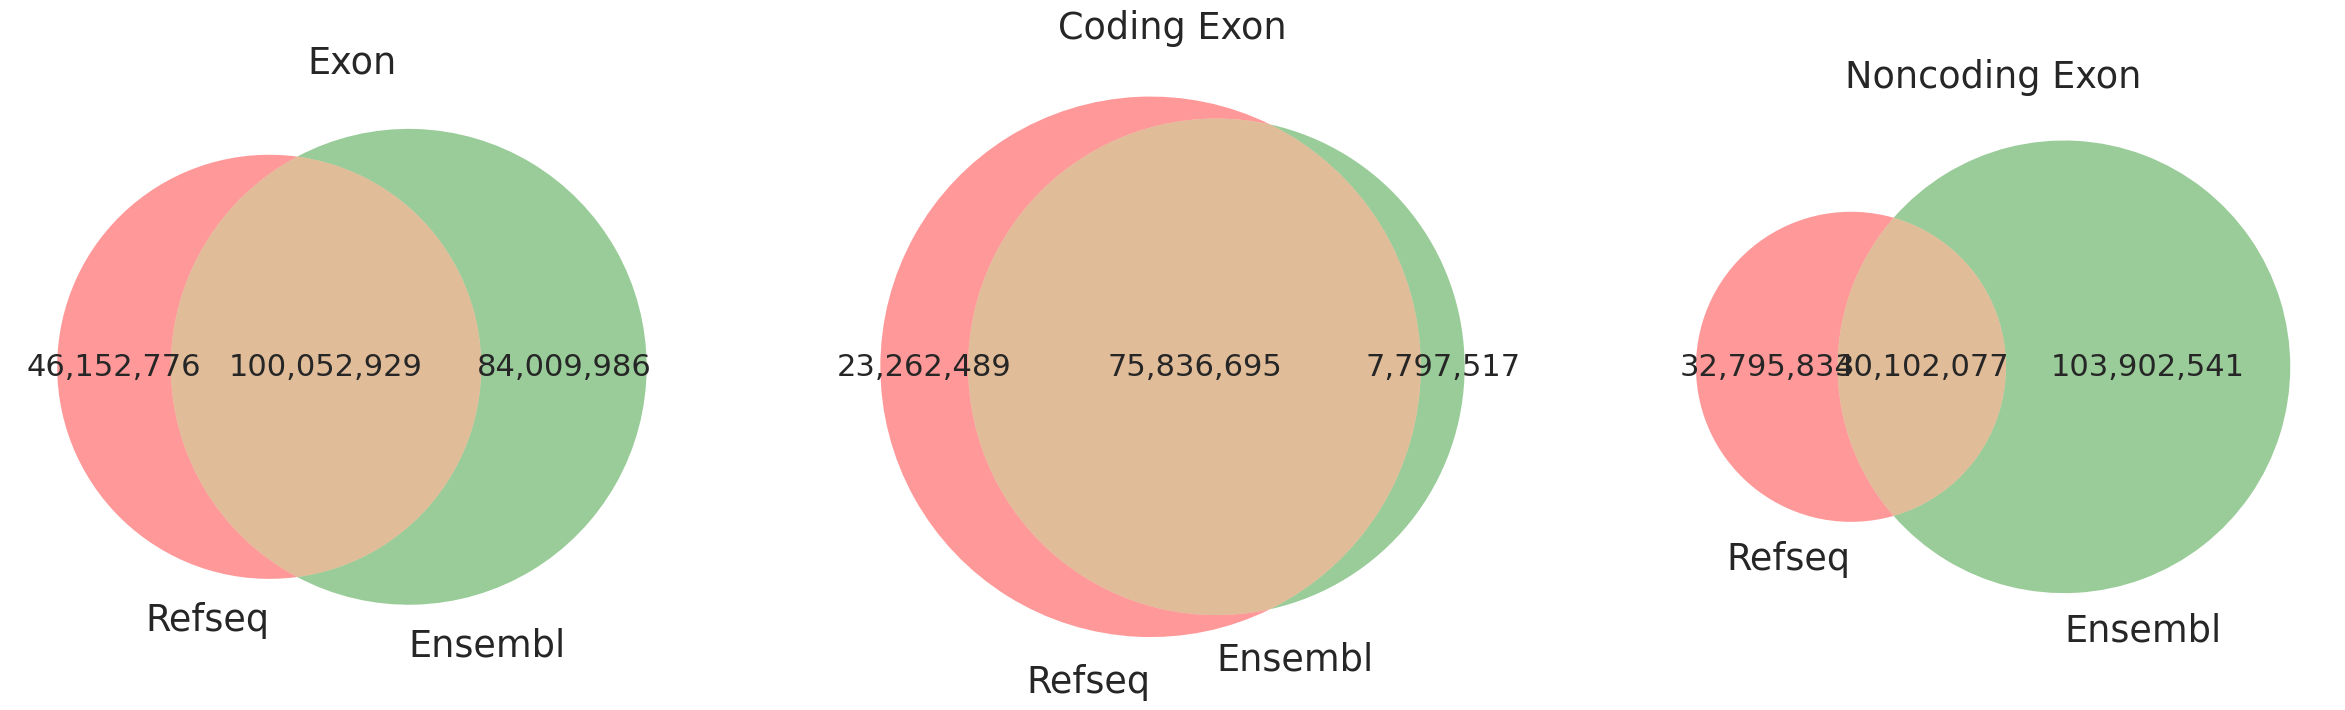

In [113]:
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
venn2(subsets=(refseq_exon_cov-intersect_exon_cov, ensembl_exon_cov-intersect_exon_cov, intersect_exon_cov), set_labels=("Refseq", "Ensembl"), ax=axes[0], subset_label_formatter=lambda x: f"{x:,}")
venn2(subsets=(refseq_coding_cov-intersect_coding_cov, ensembl_coding_cov-intersect_coding_cov, intersect_coding_cov), set_labels=("Refseq", "Ensembl"), ax=axes[1], subset_label_formatter=lambda x: f"{x:,}")
venn2(subsets=(refseq_noncoding_cov-intersect_noncoding_cov, ensembl_noncoding_cov-intersect_noncoding_cov, intersect_noncoding_cov), set_labels=("Refseq", "Ensembl"), ax=axes[2], subset_label_formatter=lambda x: f"{x:,}")
axes[0].set_title("Exon")
axes[1].set_title("Coding Exon")
axes[2].set_title("Noncoding Exon")
plt.show()



/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


166738209 62839389 134000897 30102077


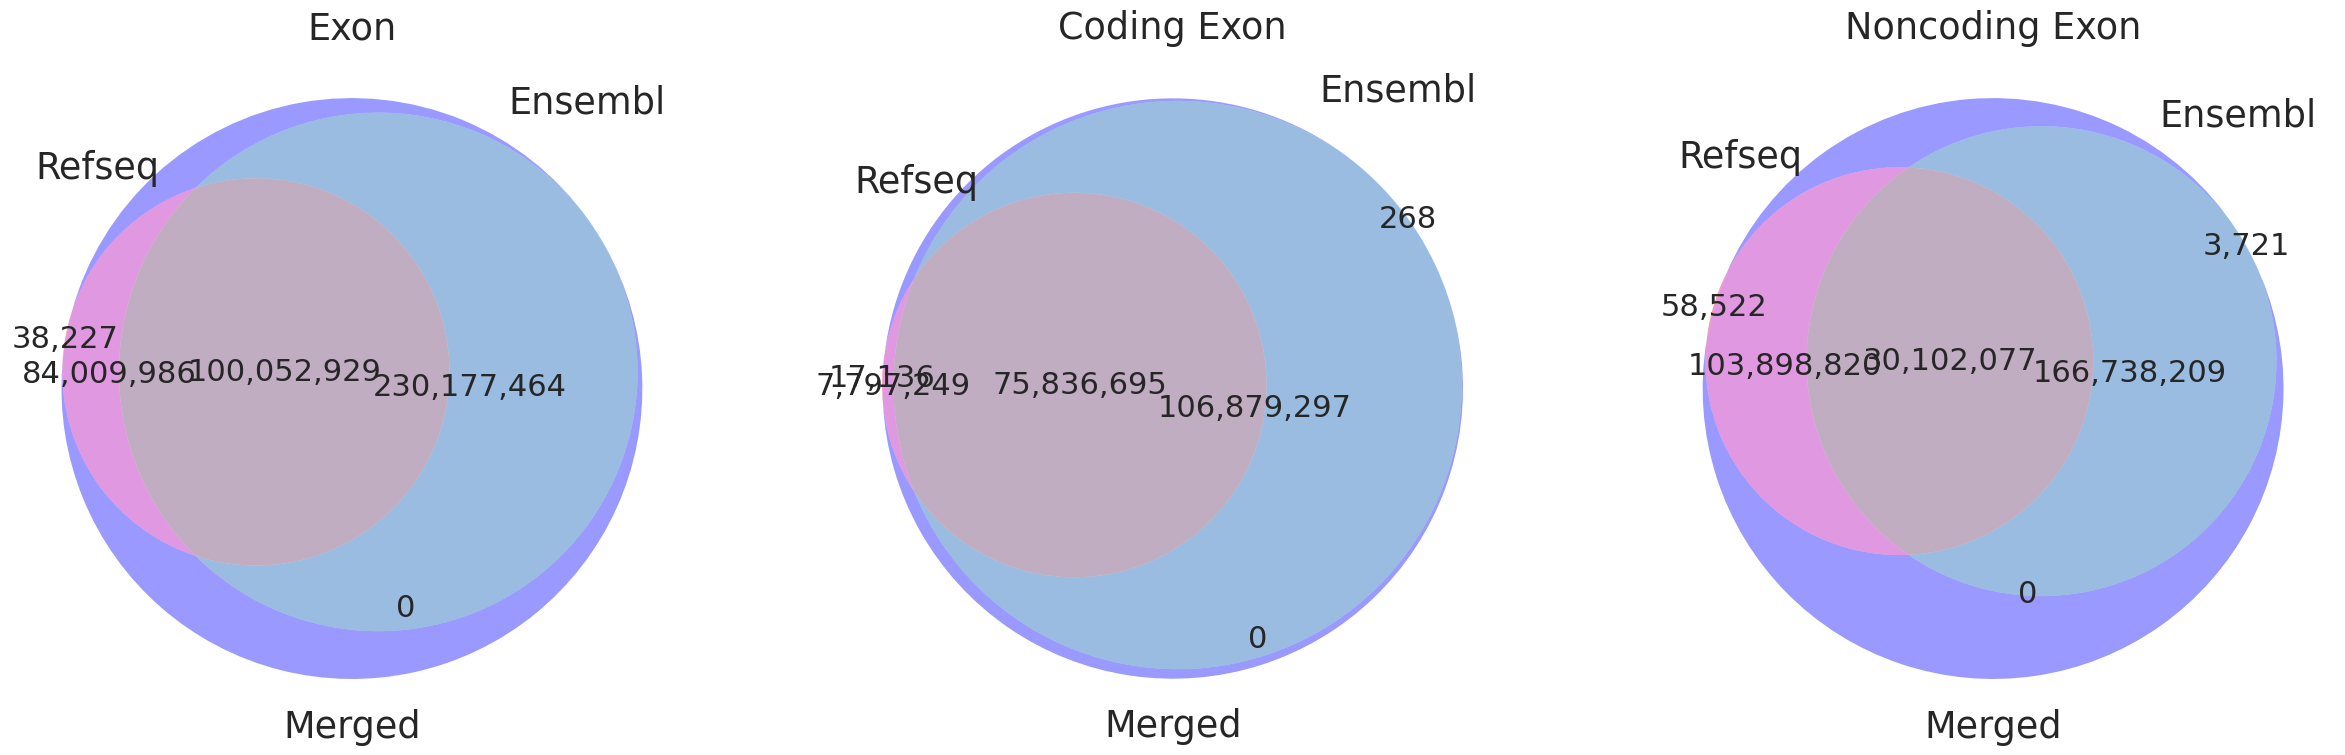

In [151]:
from matplotlib_venn import venn3

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
## Use comma for large numbers
ax = axes[0] ## exon
num_100 = refseq_exon_cov-intersect_exon_cov-intersect_merged_refseq_exon_cov+all_exon_cov
num_010 = ensembl_exon_cov-intersect_exon_cov-intersect_merged_ensembl_exon_cov+all_exon_cov
num_001 = merged_exon_cov-intersect_merged_refseq_exon_cov-intersect_merged_ensembl_exon_cov+all_exon_cov
num_110 = intersect_exon_cov-all_exon_cov
num_101 = intersect_merged_ensembl_exon_cov-all_exon_cov
num_011 = intersect_merged_refseq_exon_cov+intersect_merged_ensembl_exon_cov-all_exon_cov
num_111 = all_exon_cov

venn3(subsets=(num_100, num_010, num_110, num_001, num_101, num_011, num_111), set_labels=("Refseq", "Ensembl", "Merged"), ax=ax, subset_label_formatter=lambda x: f"{x:,}")
ax.set_title("Exon")

ax = axes[1] ## coding exon
num_100 = refseq_coding_cov-intersect_coding_cov-intersect_merged_refseq_coding_cov+all_coding_cov
num_010 = ensembl_coding_cov-intersect_coding_cov-intersect_merged_ensembl_coding_cov+all_coding_cov
num_001 = merged_exon_coding_cov-intersect_merged_refseq_coding_cov-intersect_merged_ensembl_coding_cov+all_coding_cov
num_110 = intersect_coding_cov-all_coding_cov
num_101 = intersect_merged_ensembl_coding_cov-all_coding_cov
num_011 = intersect_merged_refseq_coding_cov+intersect_merged_ensembl_coding_cov-all_coding_cov
num_111 = all_coding_cov

venn3(subsets=(num_100, num_010, num_110, num_001, num_101, num_011, num_111), set_labels=("Refseq", "Ensembl", "Merged"), ax=ax, subset_label_formatter=lambda x: f"{x:,}")
ax.set_title("Coding Exon")
    
ax = axes[2] ## noncoding exon
num_100 = refseq_noncoding_cov-intersect_noncoding_cov-intersect_merged_refseq_noncoding_cov+all_noncoding_cov
num_010 = ensembl_noncoding_cov-intersect_noncoding_cov-intersect_merged_ensembl_noncoding_cov+all_noncoding_cov
num_001 = merged_exon_noncoding_cov-intersect_merged_refseq_noncoding_cov-intersect_merged_ensembl_noncoding_cov+all_noncoding_cov
num_110 = intersect_noncoding_cov-all_noncoding_cov
num_101 = intersect_merged_ensembl_noncoding_cov-all_noncoding_cov
num_011 = intersect_merged_refseq_noncoding_cov+intersect_merged_ensembl_noncoding_cov-all_noncoding_cov
num_111 = all_noncoding_cov
print(merged_exon_noncoding_cov, intersect_merged_refseq_noncoding_cov, intersect_merged_ensembl_noncoding_cov, all_noncoding_cov)
venn3(subsets=(num_100, num_010, num_110, num_001, num_101, num_011, num_111), set_labels=("Refseq", "Ensembl", "Merged"), ax=ax, subset_label_formatter=lambda x: f"{x:,}")
ax.set_title("Noncoding Exon")
plt.show()